# Feature engineering 

Per 2 s window: time-domain stats, FFT features via FourierTransformation, magnitude signals, cross-axis correlations.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
ML4QS_CODE = ROOT.parent / 'ML4QS' / 'Python3Code'
sys.path.insert(0, str(ML4QS_CODE))
from Chapter4.FrequencyAbstraction import FourierTransformation

WIN = ROOT / 'windowed_data'
FEAT = ROOT / 'features'
FIG = ROOT / 'figures'
FEAT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

HZ = 100
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
BANDS = [(0, 1), (1, 3), (3, 5), (5, np.inf)]
BAND_NAMES = ['0_1hz', '1_3hz', '3_5hz', 'gt_5hz']
CORR_PAIRS = [
    ('acc_x', 'acc_y'), ('acc_y', 'acc_z'), ('acc_x', 'acc_z'),
    ('gyro_x', 'gyro_y'), ('gyro_y', 'gyro_z'),
]
META_COLS = {
    'participant', 'context', 'session', 'split', 'window_idx', 'label_person',
    'label_context', 'participant_id', 'label_owner', 'label_context_bin',
    'cross_session_eligible', 'has_both_contexts', 'array_idx',
}


def safe_corr(a, b):
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) else float(c)


def time_features(x, prefix):
    x = np.asarray(x, dtype=float)
    return {
        f'{prefix}_mean': np.mean(x), f'{prefix}_std': np.std(x),
        f'{prefix}_median': np.median(x), f'{prefix}_min': np.min(x),
        f'{prefix}_max': np.max(x), f'{prefix}_rms': np.sqrt(np.mean(x ** 2)),
    }


def freq_features_ml4qs(x, prefix, fs=HZ):
    x = np.asarray(x, dtype=float) - np.mean(x)
    n = len(x)
    ft = FourierTransformation()
    ft.freqs = (fs * np.fft.rfftfreq(n)).round(3)
    ft.temp_list = []
    ft.find_fft_transformation(x)
    row = ft.temp_list[0]
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    power = np.abs(np.fft.rfft(x)) ** 2
    out = {f'{prefix}_dom_freq': float(row[2]), f'{prefix}_spec_entropy': float(row[0])}
    for (lo, hi), name in zip(BANDS, BAND_NAMES):
        mask = (freqs >= lo) & (freqs < hi)
        out[f'{prefix}_band_{name}'] = float(power[mask].sum())
    return out


def extract_window_features(window):
    signals = {c: window[:, i] for i, c in enumerate(SENSOR_COLS)}
    signals['acc_magnitude'] = np.sqrt((window[:, :3] ** 2).sum(axis=1))
    signals['gyro_magnitude'] = np.sqrt((window[:, 3:] ** 2).sum(axis=1))
    feats = {}
    for name, sig in signals.items():
        feats.update(time_features(sig, name))
        feats.update(freq_features_ml4qs(sig, name))
    for a, b in CORR_PAIRS:
        feats[f'corr_{a}_{b}'] = safe_corr(signals[a], signals[b])
    return feats


def build_feature_matrix(X, meta, manifest):
    rows = []
    for i in range(len(meta)):
        row = meta.iloc[i].to_dict()
        row.update(extract_window_features(X[i]))
        rows.append(row)
    df = pd.DataFrame(rows)
    eligible = set(manifest.loc[manifest['cross_session_eligible'], 'participant'].unique())
    both_ctx = set(manifest.groupby('participant')['context'].nunique().pipe(lambda s: s[s >= 2]).index)
    df['participant_id'] = df['participant']
    df['label_owner'] = (df['participant'] == 'Pedro').astype(int)
    df['label_context_bin'] = (df['context'] == 'crowded').astype(int)
    df['cross_session_eligible'] = df['participant'].isin(eligible)
    df['has_both_contexts'] = df['participant'].isin(both_ctx)
    return df


def get_feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]

In [2]:
manifest = pd.read_csv(ROOT / 'cleaned_data' / 'manifest.csv')
meta_train = pd.read_csv(WIN / 'meta_train.csv')
meta_test = pd.read_csv(WIN / 'meta_test.csv')
X_train = np.load(WIN / 'X_train.npy')
X_test = np.load(WIN / 'X_test.npy')

train_df = build_feature_matrix(X_train, meta_train, manifest)
test_df = build_feature_matrix(X_test, meta_test, manifest)
feat_cols = get_feature_cols(train_df)

train_df[feat_cols] = train_df[feat_cols].replace([np.inf, -np.inf], np.nan)
test_df[feat_cols] = test_df[feat_cols].replace([np.inf, -np.inf], np.nan)
med = train_df[feat_cols].median()
train_df[feat_cols] = train_df[feat_cols].fillna(med)
test_df[feat_cols] = test_df[feat_cols].fillna(med)

print('Feature matrix train:', train_df[feat_cols].shape)
print('Feature matrix test:', test_df[feat_cols].shape)
print('NaNs:', int(train_df[feat_cols].isna().sum().sum()))

train_df.to_csv(FEAT / 'feature_matrix_train.csv', index=False)
test_df.to_csv(FEAT / 'feature_matrix_test.csv', index=False)

Feature matrix train: (2498, 101)
Feature matrix test: (1770, 101)
NaNs: 0


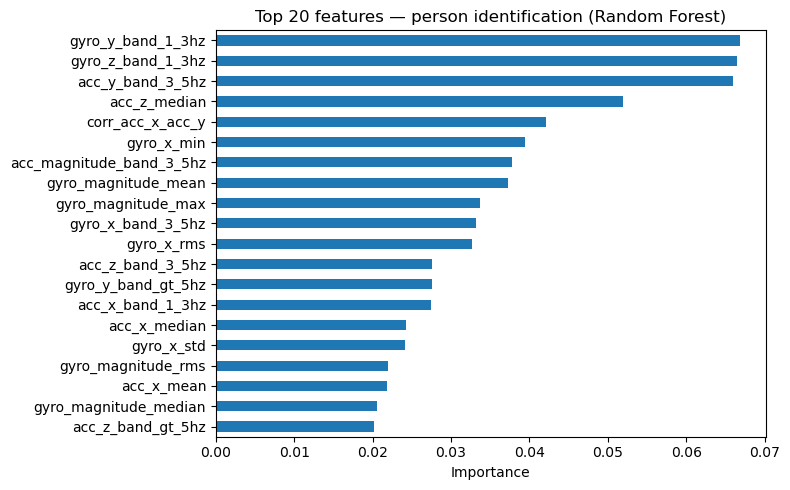

Redundant pairs |corr|>0.95: 13


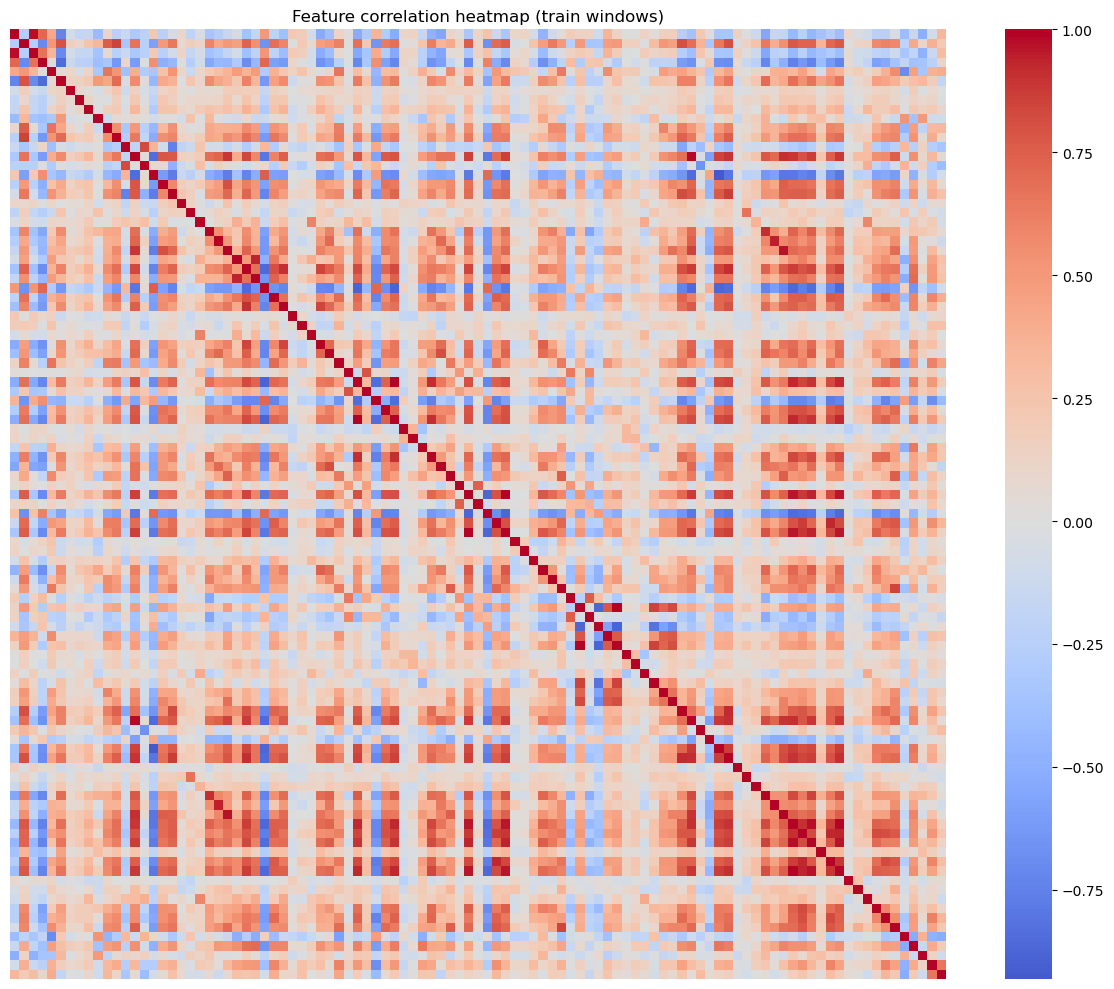

In [3]:
mask = train_df['cross_session_eligible'] & (train_df['context'] == 'normal')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_df.loc[mask, feat_cols], train_df.loc[mask, 'label_person'])
top20 = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 5))
top20.sort_values().plot.barh(ax=ax)
ax.set_title('Top 20 features — person identification (Random Forest)')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(FIG / 'fig10_feature_importance_person_id.png', dpi=150)
plt.show()

corr = train_df[feat_cols].corr().abs()
high = [(feat_cols[i], feat_cols[j], float(corr.iloc[i, j]))
        for i in range(len(feat_cols)) for j in range(i + 1, len(feat_cols)) if corr.iloc[i, j] > 0.95]
pd.DataFrame(high, columns=['feature_1', 'feature_2', 'abs_corr']).to_csv(FEAT / 'redundant_feature_pairs.csv', index=False)
print('Redundant pairs |corr|>0.95:', len(high))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(train_df[feat_cols].corr(), ax=ax, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
ax.set_title('Feature correlation heatmap (train windows)')
fig.tight_layout()
fig.savefig(FIG / 'fig11_feature_correlation_heatmap.png', dpi=150)
plt.show()